First 5 rows of the dataset:
    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000                0.0        66.0             360.0   
3             2583             2358.0       120.0             360.0   
4             6000                0.0       141.0             360.0   

   Credit_History Property_Area Loan_Status  
0             1.0         Urban           Y  
1             1.0         Rural      

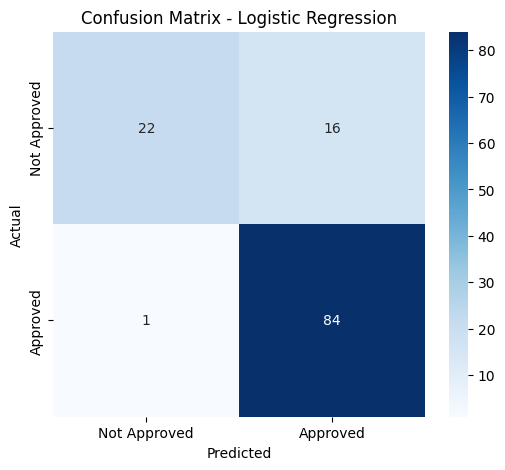

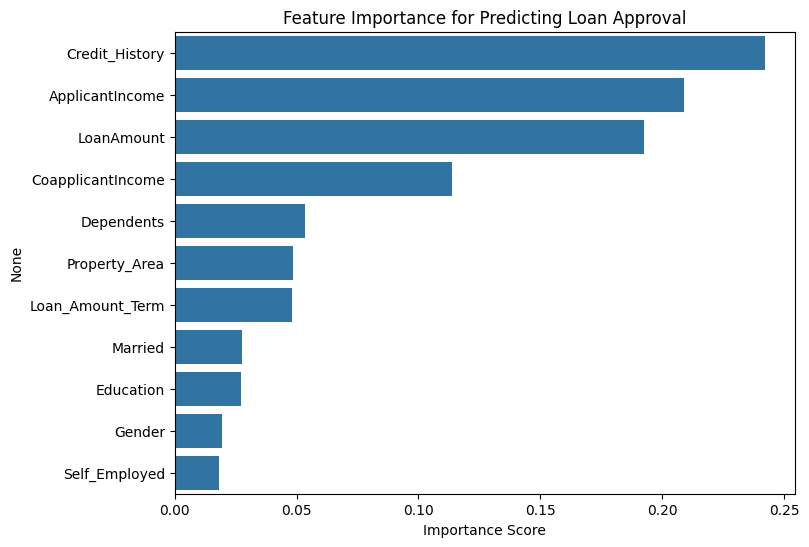


===== Full Classification Report (Best Model) =====
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [3]:
# =========================================================
# TASK 3: Loan Approval Prediction
# =========================================================
# This script does the following step by step:
# 1. Load the data
# 2. Handle missing values and encode categorical features
# 3. Train classification models and compare performance
# 4. Evaluate using confusion matrix and accuracy
# =========================================================

# ---- Step 1: Import required libraries ----
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ---- Step 2: Load the dataset ----
# NOTE: The dataset file must be uploaded to Colab first
# Kaggle file is usually named 'train.csv' or 'loan_prediction.csv'
# Check your downloaded file's actual name and update it below if needed
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape (rows, columns):", df.shape)

print("\nColumn info:")
print(df.info())

print("\nChecking for missing values:")
print(df.isnull().sum())

# ---- Step 3: Drop the ID column (not useful for prediction) ----
if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

# ---- Step 4: Handle missing values ----
# For numeric columns, fill missing values with the median
# For categorical (text) columns, fill missing values with the most common value (mode)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# ---- Step 5: Encode categorical columns ----
# 'Loan_Status' is our target column, we handle it separately at the end
target_col = 'Loan_Status'
feature_categorical_cols = [c for c in categorical_cols if c != target_col]

le = LabelEncoder()
df_encoded = df.copy()

for col in feature_categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Encode the target column: Y -> 1 (Approved), N -> 0 (Not Approved)
df_encoded[target_col] = df_encoded[target_col].map({'Y': 1, 'N': 0})

# ---- Step 6: Separate Features (X) and Target (y) ----
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print(f"\nFeatures used: {X.columns.tolist()}")
print(f"\nTarget value counts:\n{y.value_counts()}")

# ---- Step 7: Train/Test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

# ---- Step 8: Feature Scaling (for Logistic Regression) ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---- Step 9: Train and compare multiple classification models ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1
    }

    print(f"\n===== {name} =====")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")

# ---- Step 10: Compare all model results in a table ----
results_df = pd.DataFrame(results).T
print("\n===== Comparison of All Models =====")
print(results_df)

# ---- Step 11: Identify the best model (based on F1-Score) ----
best_model_name = results_df['F1-Score'].idxmax()
print(f"\nBest model (based on F1-Score): {best_model_name}")

best_model = models[best_model_name]
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# ---- Step 12: Plot Confusion Matrix for the best model ----
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print("\n")
# ---- Step 13: Feature Importance (using Random Forest) ----
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance for Predicting Loan Approval")
plt.xlabel("Importance Score")
plt.show()

print("\n===== Full Classification Report (Best Model) =====")
print(classification_report(y_test, y_pred_best))
